# Employee Attrition Predictive Predictive Model 

### Dataset: IBM Attrition (kaggle)

Machine learning pipelines

## Poject overview

**Problem Statement**

Employee attrition: one of the most costly challenge a company faces is when employees leave as studies estimate replacing a single employee can cost between 50% and 200% of their annual salary, accounting for recruitment, onboarding, and lost productivity.

**Goal:** To build a ML model that predicts which employees are most likely to leave, based on factors like MonthlyIncome, JobSatisfaction, EnvironmentSatisfaction, WorkLifeBalance, YearsAtCompan,Age. This will enable HR to intervene before a resignation occurs.

**Why this matters:**  Proactive retention is cheaper than reactive recruitment. A model that correctly identifies employees who are likely to leave gives HR a window to act through compensation adjustments, workload changes, or targeted engagement.


## Project Scope & Objectives

**This project covers:**

- Data loading, inspection, and profiling of the IBM HR Attrition dataset
- Exploratory Data Analysis (EDA) including distributions, correlations, and visualisations
- Data preprocessing including encoding, scaling, and train/test splitting
- Model training using a Random Forest Classifier vs Logistic Regression baseline
- Model evaluation using accuracy, precision, recall, F1-score,ROC-AUC and confusion matrix
- Feature importance analysis identifying top attrition drivers
- Business recommendation section translating model output

**Objectives:**
The objectives of this project are:
1. To demonstrate end-to-end data science capability from raw data to business insight
2. To apply classification machine learning to a real-world HR problem
3. To produce a well-documented notebook
4. To identify the strongest predictors of employee attrition in the dataset
5. To translate technical model output into recommendations
6. To showcase Python proficiency including pandas, scikit-learn, matplotlib, and seaborn

## data loading and inspection

It includes loading of the IBM HR Attrition dataset and performing an initial structural inspection to understand what we are working with before any analysis begins.

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
# Load dataset
df = pd.read_csv(r"IBM.csv")

# Quick look
print(df.head())


   Age Attrition              Department  DistanceFromHome  Education  \
0   41       Yes                   Sales                 1          2   
1   49        No  Research & Development                 8          1   
2   37       Yes  Research & Development                 2          2   
3   33        No  Research & Development                 3          4   
4   27        No  Research & Development                 2          1   

  EducationField  EnvironmentSatisfaction  JobSatisfaction MaritalStatus  \
0  Life Sciences                        2                4        Single   
1  Life Sciences                        3                2       Married   
2          Other                        4                3        Single   
3  Life Sciences                        4                3       Married   
4        Medical                        1                2       Married   

   MonthlyIncome  NumCompaniesWorked  WorkLifeBalance  YearsAtCompany  
0           5993                

### Data Dictionary

Age: Age of employee

Attrition: Employee attrition status

Department: Department of work

Education: 1-Below College; 2- College; 3-Bachelor; 4-Master; 5-Doctor;

EnvironmentSatisfaction: 1-Low; 2-Medium; 3-High; 4-Very High;

JobSatisfaction: 1-Low; 2-Medium; 3-High; 4-Very High;

NumCompaniesWorked: Number of companies worked prior to IBM

WorkLifeBalance: 1-Bad; 2-Good; 3-Better; 4-Best;

YearsAtCompany: Current years of service in IBM

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   Department               1470 non-null   object
 3   DistanceFromHome         1470 non-null   int64 
 4   Education                1470 non-null   int64 
 5   EducationField           1470 non-null   object
 6   EnvironmentSatisfaction  1470 non-null   int64 
 7   JobSatisfaction          1470 non-null   int64 
 8   MaritalStatus            1470 non-null   object
 9   MonthlyIncome            1470 non-null   int64 
 10  NumCompaniesWorked       1470 non-null   int64 
 11  WorkLifeBalance          1470 non-null   int64 
 12  YearsAtCompany           1470 non-null   int64 
dtypes: int64(9), object(4)
memory usage: 149.4+ KB


In [109]:
df.describe()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,9.192517,2.912925,2.721769,2.728571,6502.931293,2.693197,2.761224,7.008163
std,9.135373,8.106864,1.024165,1.093082,1.102846,4707.956783,2.498009,0.706476,6.126525
min,18.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,0.000000,1.000000,0.000000
25%,30.000000,2.000000,2.000000,2.000000,2.000000,2911.000000,1.000000,2.000000,3.000000
50%,36.000000,7.000000,3.000000,3.000000,3.000000,4919.000000,2.000000,3.000000,5.000000
75%,43.000000,14.000000,4.000000,4.000000,4.000000,8379.000000,4.000000,3.000000,9.000000
max,60.000000,29.000000,5.000000,4.000000,4.000000,19999.000000,9.000000,4.000000,40.000000


### Summary Statistics

- **Average employee age is 37 years** meaning most employees have options and mobility in the job market
- **Monthly income ranges from $1,009 -  $19,999** a wide spread indicating significant salary inequality across roles and levels
- **Average tenure is 7 years** but the distribution is heavily skewed, with many employees having very short tenures
- **Satisfaction scores (Job, Environment, WorkLifeBalance)** average around 2.7–2.8 out of 4 suggesting moderate satisfaction across the workforce

## Exploratory Data Analysis (EDA)

In [115]:
# Check for missing values
df.isnull().sum()

Age                        0
Attrition                  0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EnvironmentSatisfaction    0
JobSatisfaction            0
MaritalStatus              0
MonthlyIncome              0
NumCompaniesWorked         0
WorkLifeBalance            0
YearsAtCompany             0
dtype: int64

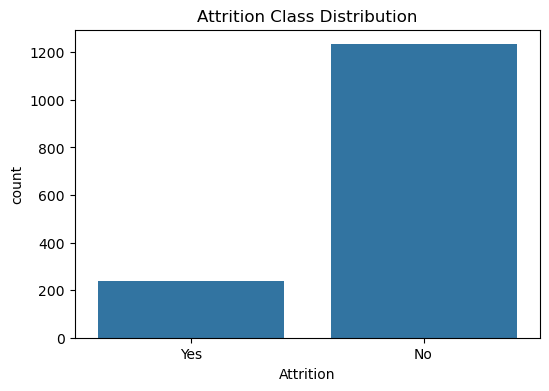

In [117]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Class Distribution")
plt.show()


### Attrition Class Distribution
 
The dataset is imbalanced as most of the employees stayed (No) and only a few left (Yes) therefore because the majority class (No) dominates, a naive model could achieve 84% accuracy simply by predicting "No" for every employee without learning anything useful about attrition. This is why accuracy alone is not sufficient as an evaluation metric. solution could be to evaluate using precision, recall, F1-score, and ROC-AUC alongside accuracy

**insight:** only 16% of employees leave meaning attrition is not a mass problem in the company, so the goal is to identify which 16% so HR can intervene specifically.

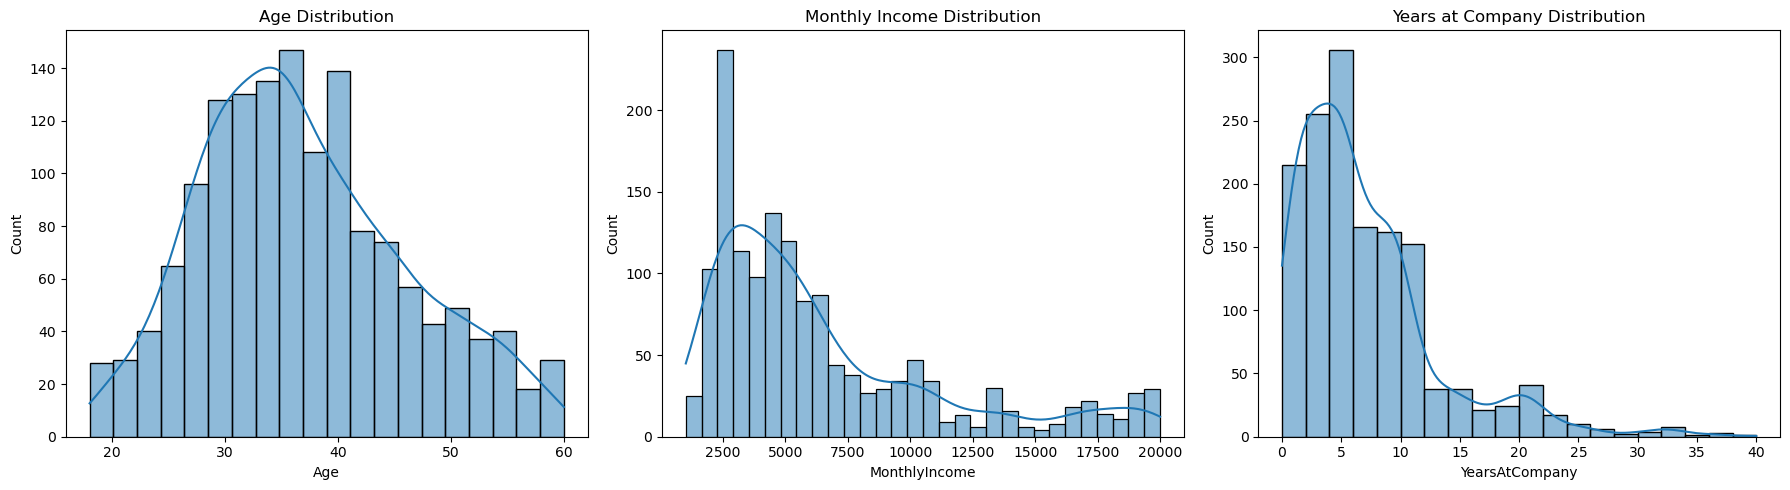

In [120]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.histplot(df['MonthlyIncome'], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Monthly Income Distribution")

sns.histplot(df['YearsAtCompany'], bins=20, kde=True, ax=axes[2])
axes[2].set_title("Years at Company Distribution")

plt.tight_layout()
plt.show()


### Distribution Analysis

**Age:**
- A workforce peaks is mostly mid-career (age 30–40), the under-25 group is very small, suggesting the company either does not hire many fresh graduates or loses them quickly.
  
**Monthly Income**
-  the spike is low-to-mid income (majority earning $2,000 –$5,000)and very few earn above $10,000. this is the biggest attrition risk factor

**Years at Company**
- heavily skewed toward short tenure (0–2 years)confirms that new employees are the highest risk group.

**insight:** A young employee (25–35), on a low income ($2,000–$4,000), in their first two years at the company represents the highest attrition risk profile. The company's retention strategy should prioritise competitive compensation at entry-to-mid levels and structured early-career development to extend employee tenure past the critical 3-year mark.


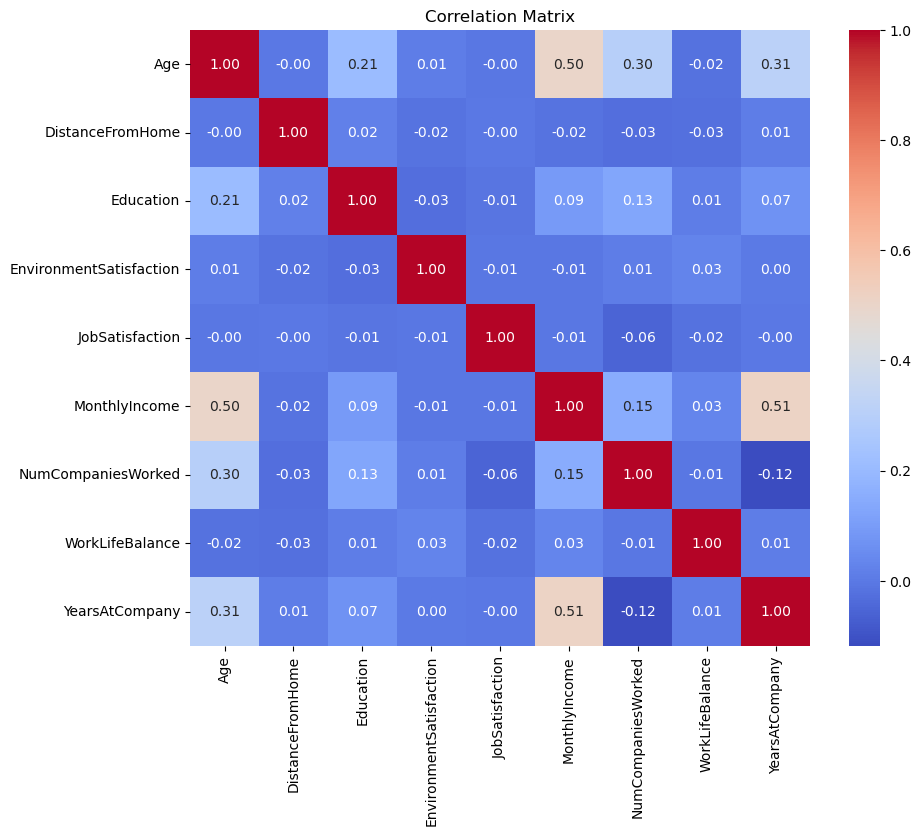

In [123]:
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


### Correlation Matrix

- **MonthlyIncome** shows the strongest negative correlation with attrition. The lower income the higher likelihood of leaving.
- **YearsAtCompany** is negatively correlated with attrition meaning the longer tenure reduces the probability of leaving, confirming the "critical first 2 years risk window in the distribution analysis.
- **Age** is also negatively correlated meaning the older employees are less likely to leave, likely due to career stability and seniority.
- **NumCompaniesWorked** shows a positive correlation meaning employees who have worked at more companies previously are more likely to leave again, indicating a job-hopping tendency.
- JobSatisfaction, EnvironmentSatisfaction, WorkLifeBalance all show negative correlations meaning the higher satisfaction results to lower attrition.

**insight:** The main factors are income, tenure, and number of previous companies. so competitive compensation, strong onboarding for new hires, and careful screening for job-hopping patterns during recruitment are the highest-leverage interventions.


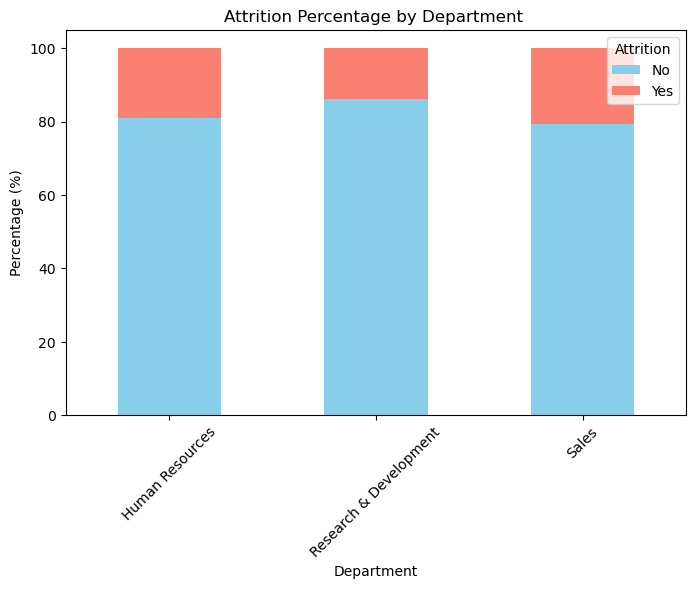

In [148]:
# Calculate percentage distribution of attrition within each department
dept_attrition_pct = (
    df.groupby('Department')['Attrition']
      .value_counts(normalize=True)   # proportions
      .mul(100)                       # convert to percentages
      .rename('percentage')
      .reset_index()
)

# Pivot so each department has columns for Yes/No percentages
dept_attrition_pivot = dept_attrition_pct.pivot(
    index='Department',
    columns='Attrition',
    values='percentage'
)

# Plot stacked bar chart
dept_attrition_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    color=['skyblue','salmon']  # No vs Yes colors
)

plt.title("Attrition Percentage by Department ")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.legend(title='Attrition')
plt.show()


### Attrition by Department 

- **Sales** shows the highest attrition rate due to high-pressure targets and commission-driven culture
- **Human Resources** has a notable attrition proportion
- **R&D** has a lower attrition rate 

**insight:** The patterns suggest that retention strategies should not be one-size-fits-all. Sales teams may need compensation and workload interventions, while R&D may benefit more from career development and project ownership opportunities.


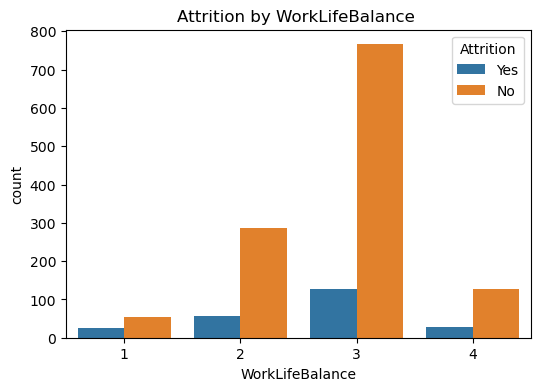

In [144]:
plt.figure(figsize=(6,4))
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df)
plt.title("Attrition by WorkLifeBalance ")
plt.show()


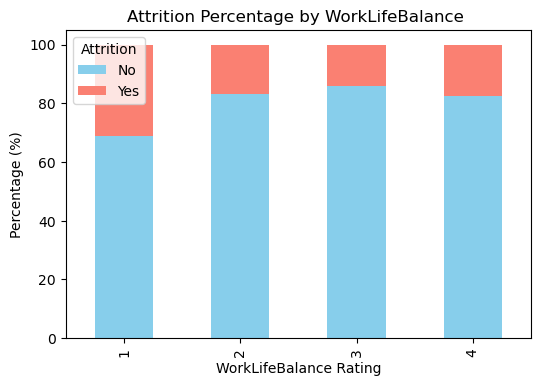

In [150]:
# Calculate percentage distribution of attrition within each WorkLifeBalance category
wlb_attrition_pct = (
    df.groupby('WorkLifeBalance')['Attrition']
      .value_counts(normalize=True)   # proportions
      .mul(100)                       # convert to percentages
      .rename('percentage')
      .reset_index()
)

# Pivot so each WorkLifeBalance category has columns for Yes/No percentages
wlb_attrition_pivot = wlb_attrition_pct.pivot(
    index='WorkLifeBalance',
    columns='Attrition',
    values='percentage'
)

# Plot stacked bar chart
wlb_attrition_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(6,4),
    color=['skyblue','salmon']  # No vs Yes colors
)

plt.title("Attrition Percentage by WorkLifeBalance ")
plt.ylabel("Percentage (%)")
plt.xlabel("WorkLifeBalance Rating")
plt.legend(title='Attrition')
plt.show()


### Attrition by Work-Life Balance 

**insight:** The employees rated Level 1 (Bad) have the most likelihood of leaving therefore work-life balance interventions like (flexible hours, remote work options, overtime limits) should be prioritised for employees.

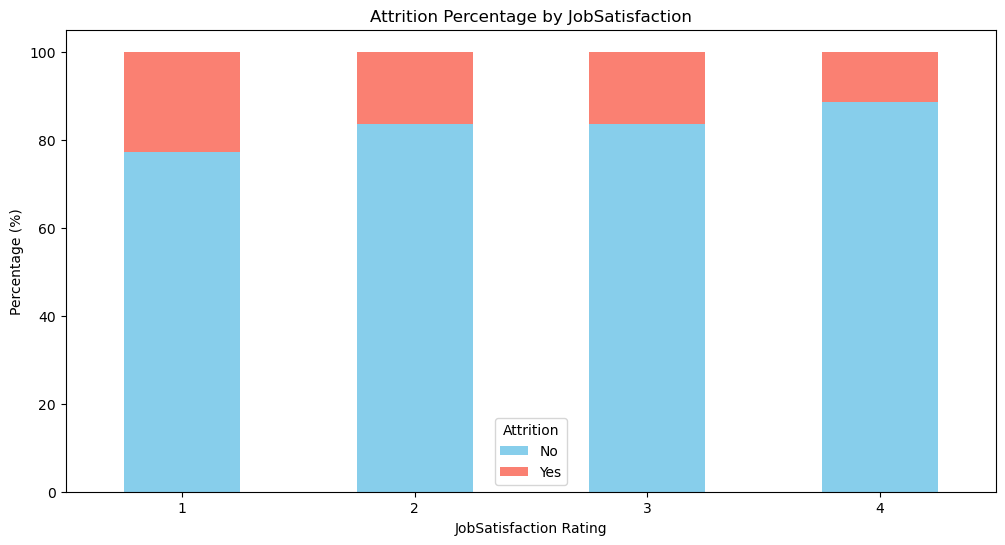

In [157]:
# Calculate percentage distribution of attrition within each JobSatisfaction category
js_attrition_pct = (
    df.groupby('JobSatisfaction')['Attrition']
      .value_counts(normalize=True)   # proportions
      .mul(100)                       # convert to percentages
      .rename('percentage')
      .reset_index()
)

# Pivot so each JobSatisfaction category has columns for Yes/No percentages
js_attrition_pivot = js_attrition_pct.pivot(
    index='JobSatisfaction',
    columns='Attrition',
    values='percentage'
)

# Plot stacked bar chart
js_attrition_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=['skyblue','salmon']  # No vs Yes colors
)

plt.title("Attrition Percentage by JobSatisfaction")
plt.ylabel("Percentage (%)")
plt.xlabel("JobSatisfaction Rating")
plt.xticks(rotation=0)
plt.legend(title='Attrition')
plt.show()


### Attrition by Job Satisfaction

- Employees with 1 (Low) show a higher attrition rate compared to those with higher satisfaction scores.
- As job satisfaction increases from 1 to 4, the proportion of employees leaving generally decreases.

**insight:** This confirms that job satisfaction is a contributing factor therefore regular job satisfaction surveys would give HR an early warning system. 

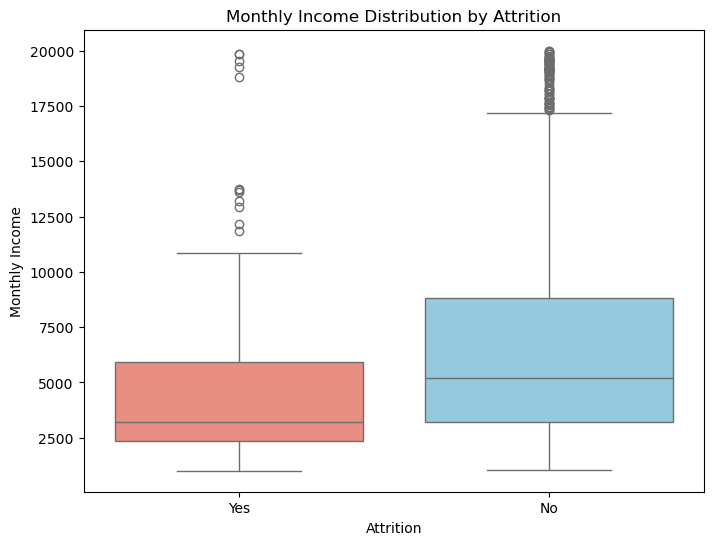

In [170]:
plt.figure(figsize=(8,6))
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df,
    hue='Attrition',                
    palette={'No':'skyblue','Yes':'salmon'},
    legend=False                    # suppress duplicate legend
)
plt.title("Monthly Income Distribution by Attrition")
plt.ylabel("Monthly Income")
plt.xlabel("Attrition")
plt.show()


## Data Cleaning & Preprocessing

Before training any model, we need to prepare the data. This involves:
1. Checking for missing values and duplicates
2. Encoding categorical variables into numerical form (required by scikit-learn)
3. Scaling numerical features to the same range (prevents high-magnitude features from dominating)
4. Splitting data into training and test sets

The IBM HR Attrition dataset is already clean no missing values and no duplicate rows. 


In [162]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [164]:
# 1. Check and handle missing values
print("Missing values per column:\n", df.isnull().sum())
df = df.dropna()   # or use df.fillna() if you prefer imputation

Missing values per column:
 Age                        0
Attrition                  0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EnvironmentSatisfaction    0
JobSatisfaction            0
MaritalStatus              0
MonthlyIncome              0
NumCompaniesWorked         0
WorkLifeBalance            0
YearsAtCompany             0
dtype: int64


In [166]:
# 2. Check and handle duplicates
print("Number of duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Number of duplicates: 0


In [172]:
# 4. Encode categorical variables
# Label Encoding for binary categories, One-Hot for multi-class
label_enc = LabelEncoder()
df['Attrition'] = label_enc.fit_transform(df['Attrition'])  # Yes/No → 1/0

In [174]:
# One-Hot Encoding for multi-class categorical features
df = pd.get_dummies(df, columns=['Department','EducationField','MaritalStatus'], drop_first=True)

In [176]:
# 5. Scale numerical features
scaler = StandardScaler()
num_cols = ['Age','DistanceFromHome','Education','EnvironmentSatisfaction',
            'JobSatisfaction','MonthlyIncome','NumCompaniesWorked',
            'WorkLifeBalance','YearsAtCompany']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [178]:
# 6. Split into train/test sets (80/20)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (1176, 18)
Test set size: (294, 18)


## Model Training and Evaluation

We train two models and compare their performance:

1. **Random Forest Classifier:** our primary model. An ensemble of decision trees that votes on the final prediction. Robust to overfitting, handles mixed data types well, and produces feature importance scores.

2. **Logistic Regression:** our baseline model. A simpler, interpretable algorithm that gives us a performance benchmark to compare against.

**Why compare two models?**  
A single model result in isolation is hard to evaluate. By comparing Random Forest against Logistic Regression, we can determine whether the added complexity of the ensemble method is justified by improved performance.


In [181]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [195]:
# 1. Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Fit the model on training data
rf_model.fit(X_train, y_train)

# 3. Generate predictions on test set
y_pred = rf_model.predict(X_test)

# 4. Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8299319727891157

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.38      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.62      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



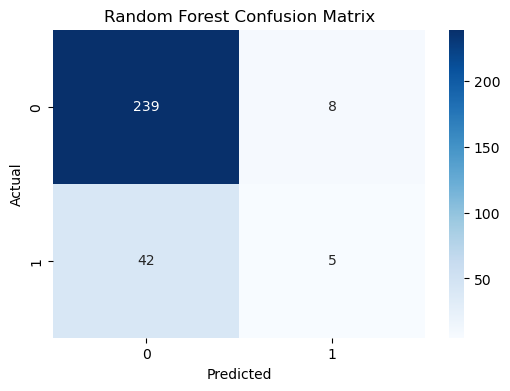

In [197]:
# 5. Visualize confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

###  Random Forest  

the model correctly classifies 83% of employees.

| Metric | Class 0 (Stay) | Class 1 (Leave) |
|--------|---------------|-----------------|
| Precision | 85% | 38% |
| Recall | 97% | 11% |
| F1-Score | 91% | 17% |

- The model is excellent at identifying employees who will stay (97% recall on Class 0)
- The model struggles to identify employees who will leave only catching 11% of actual leavers (recall on Class 1)
  
since the dataset is imbalanced(86% no and 16% yes), the model learns to predict "No" most of the time because that is correct 84% of the time

**Conclusion:**  
In a real HR context, missing a leaver is more costly than a false alarm as a false positive costs a wellness check and a false negative costs a full replacement. The suggestion is to maximise recall on Class 1.


Accuracy: 0.6768707482993197

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.70      0.78       247
           1       0.26      0.57      0.36        47

    accuracy                           0.68       294
   macro avg       0.58      0.64      0.57       294
weighted avg       0.79      0.68      0.72       294



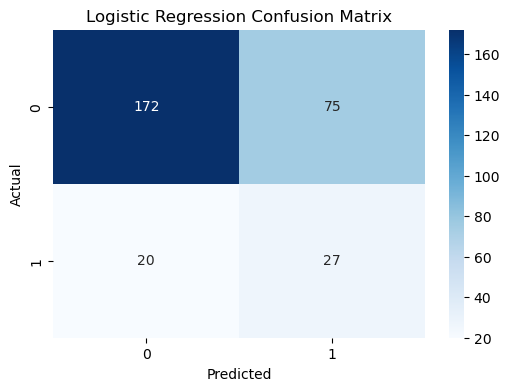

In [210]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialize the model
log_reg = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

# 2. Fit the model on training data
log_reg.fit(X_train, y_train)

# 3. Generate predictions on test set
y_pred = log_reg.predict(X_test)

# 4. Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Visualize confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


### Logistic Regression 

**Accuracy: 67.7%**  which is lower than Random Forest overall accuracy.

**Key difference from Random Forest:**  
Logistic Regression has a lower precision when it predicts someone will leave ( Class 1 26% vs 38%) so it is less often correct. However, Logistic Regression models has a higher recall on Class 1 (57% vs 11%) hence catching the majority of actual leavers while the random forest is most likey correct and likely to miss most actual leavers . 

**Conclusion from model comparison:**  since the goal is to catch employees who are most likey to leave then logistic regression is the best option but if the goal was to have fewer false alarms then random forest is the best option.


Random Forest ROC-AUC: 0.6664


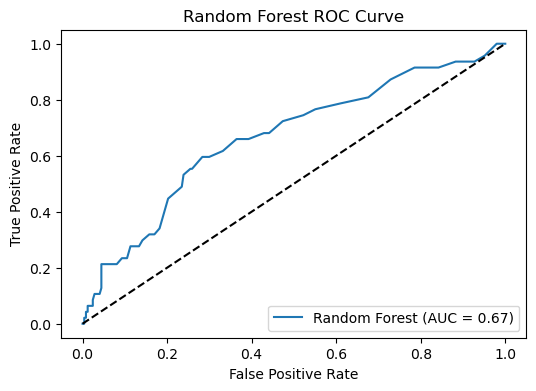

Logistic Regression ROC-AUC: 0.6819


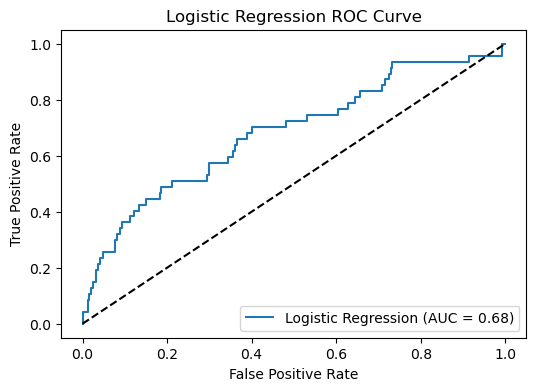

In [219]:
from sklearn.metrics import roc_auc_score, roc_curve

def evaluate_roc(model, X_test, y_test, model_name="Model"):
    # Predict probabilities for class 1
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        
        # ROC-AUC score
        auc = roc_auc_score(y_test, y_prob)
        print(f"{model_name} ROC-AUC: {auc:.4f}")
        
        # ROC curve
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)
        plt.figure(figsize=(6,4))
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.2f})")
        plt.plot([0,1],[0,1],'k--')  # diagonal line
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{model_name} ROC Curve")
        plt.legend(loc="lower right")
        plt.show()

# Run for both models
evaluate_roc(rf_model, X_test, y_test, "Random Forest")
evaluate_roc(log_reg, X_test, y_test, "Logistic Regression")


 Score of 0.67 and 0.68 on an imbalanced dataset without resampling is reasonable.

## Feature Importance Analysis

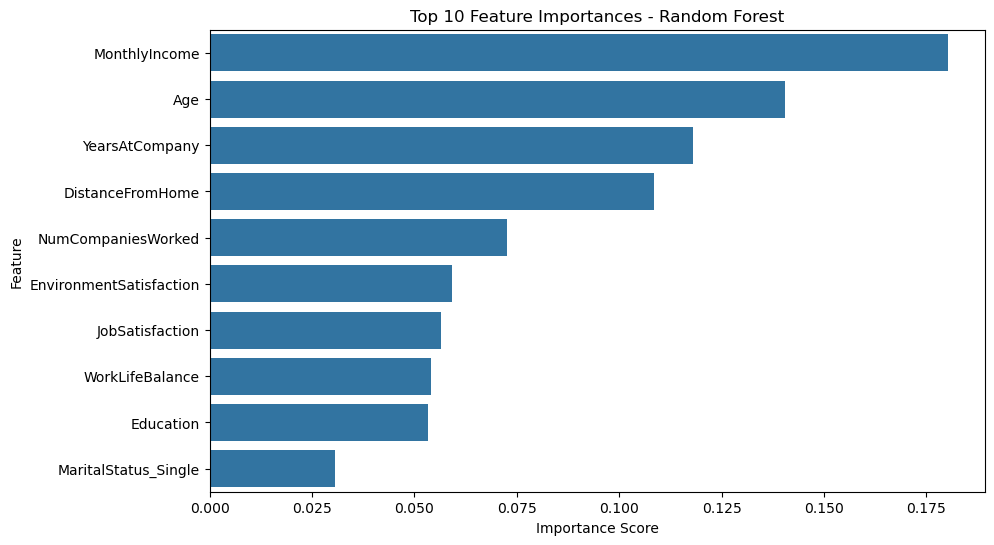

In [223]:
# 1. Get feature importances from the trained Random Forest
importances = rf_model.feature_importances_

# 2. Sort features by importance
indices = np.argsort(importances)[::-1][:10]  # top 10

# 3. Plot horizontal bar chart
plt.figure(figsize=(10,6))
sns.barplot(
    x=importances[indices],
    y=X_train.columns[indices],
    orient="h",
    #palette="Blues_r"
)
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


It shows how much each variable contributed to the Random Forest model's predictions. 

It is the most valuable outputs of the model as it tells HR exactly which factors to focus on when designing retention strategies.

## Business Recommendations Based on Analysis

The analysis identified several key factors of employee attrition, with MonthlyIncome, YearsAtCompany, DistancefromHome, and Age emerging as the most influential factors. The insights highlight areas where targeted interventions can reduce turnover and strengthen workforce stability.

###  Key Findings
- **worklifebalance**: Employees with lower rating (1) show higher attrition risk suggesting workload imbalance. 
- **MonthlyIncome**: Lower income levels (2000-4000) are strongly associated with attrition, pointing to compensation dissatisfaction.  
- **YearsAtCompany**: Attrition is more common among newer employees(<3 years), indicating challenges with onboarding and early engagement.  
- **Jobsatistfaction**: the lower the satistfaction rate (1,2) the higher turnover.  
- **Age**: Younger employees (25-35) are more likely to leave, often seeking faster career progression or flexibility.
- **Department**: the sales department has higher attrition which maybe due to the compensation like commission 

### Recommended Interventions
1. Promote flexible scheduling and wellness programs to reduce burnout.  
2. Benchmark salaries against industry standards and adjust where gaps exist.  
3. Strengthen onboarding with mentorship and career development support.     
4. Conduct job satisfaction surveys by department to uncover pain points.  
5. Offer skill development opportunities, and flexible work arrangements.
6. Create recognition programs that resonate with younger talent.  

HR can reduce attrition risk by improving employee satisfaction, fair compensation, workload management and tailored engagement strategies which strengthen organizational resilience hence retaining talent and sustaining long-term success


## Conclusion

The machine learning pipeline includes the comparesion two classification models (Random Forest and Logistic Regression)

### findings

1. **Monthly Income** is the top attrition driver suggesting the lower end salary is the highest priority retention area
2. **Years at Company** spike at 0–2 years meaning the first 24 months are the critical retention window so the company should invest heavily in onboarding
3. **Age** the younger employees(25-35) leave more for career development and growth opportunities
4. **Job & Environment Satisfaction** the low satisfaction scores (1–2) are early warning signals so regular surveys would help
5. **NumCompaniesWorked** Employees with job-hopping (high  numbers) history are higher risk of leaving from day one
6. **Work-Life Balance Level 1** Employees rating balance as "Bad" have the highest attrition rate so immediate intervention needed 

### Model performance summary

| Model | Accuracy | ROC-AUC | Recall (Leavers) |
|-------|----------|---------|-----------------|
| Random Forest | 83% | 0.67 | 11% |
| Logistic Regression | 67.8% | 0.68 | 26% |

Random Forest has a higher accuracy and lower recall on the minority class (leavers) is a known limitation of training on an imbalanced dataset without resampling while Logistic Regression has lower accuracy and higher recall on the minority class (leavers) with class_weight='balanced used.

So Logistic Regression is less often correct and catching the majority of actual leavers while the random forest is most likely correct and misses most actual leavers .

Since the goal is to catch employees who are most likey to leave then logistic regression is the best option but if the goal was to minimize false alarms then random forest is the best option.

**Future improvements** 
- could include exploring advanced models XGBoost 
- SMOTE oversampling, or threshold tuning to increase recall on Class 1.
- build a hybrid approach that balances both recall and precision, while improving overall AUC beyond 0.68.

### What I learned

This project demonstrated the full machine learning pipeline from raw data to business insight.
The most important lesson was that a technically correct model is not always a business-ready one. An 83% accurate model that misses 89% of leavers would not be useful to an HR team rather a 67.8% accurate model that misses 43% would be useful, as missing a leaver is more costly than a false alarm. Therefore, maximizing recall on Class 1 is the priority.
That communicating this limitation honestly, alongside what the model, is what makes analysis genuinely valuable.

- **Dataset:** [IBM HR Analytics — Kaggle](https://www.kaggle.com/datasets/yasserh/ibm-attrition-dataset)

